**Task 1 — Business Understanding**

- Target variable: `charges` (insurance medical cost) — the company's financial concern.
- Candidate inputs (customer risk factors): `age`, `sex`, `bmi`, `children`, `smoker`, `region`, and any derived features.

How regression helps: a fitted regression model quantifies the marginal effect of each variable on charges (holding others constant). Management can use statistically significant, high-impact predictors (e.g., `smoker`, `bmi`) to design risk-based premiums, target interventions (wellness programs), and control losses by pricing or policy design rather than only forecasting aggregate cost.

In [ ]:
# Task 2 — Data load & quick inspection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df=pd.read_csv('insurance.csv')

# Quick peek
display(df.head())
print('Shape:', df.shape)
print('Columns and dtypes:')
print(df.dtypes)

Loaded: insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Shape: (1338, 7)
Columns and dtypes:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [2]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print('Numeric cols:', numeric_cols)
print('Categorical cols:', categorical_cols)

# Columns that are not directly usable (text, ids, etc.)
# In this dataset, categorical columns like 'sex', 'smoker', 'region' need encoding before regression.

# Data quality checks
print('Missing values per column:', df.isna().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Unique counts for categorical columns:')
for c in categorical_cols:
    print(c, ':', df[c].nunique())

Numeric cols: ['age', 'bmi', 'children', 'charges']
Categorical cols: ['sex', 'smoker', 'region']
Missing values per column: age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicate rows: 1
Unique counts for categorical columns:
sex : 2
smoker : 2
region : 4


**Task 3 — Data Cleaning & Encoding (business + modeling justification)**

- `sex`: binary (male/female). Map to `sex_male` = 1 if male, 0 if female. This is straightforward for interpretation and keeps coefficient meaning clear (difference vs baseline).
- `smoker`: binary (yes/no). Map to `smoker_yes` = 1 if smoker, 0 if non-smoker. This is typically a major driver of charges and economically meaningful.
- `region`: categorical with multiple levels. Use one-hot encoding (drop one level) so each region's effect is estimated relative to the baseline region. If there are geographic groups with an ordering or strong spatial correlation, consider grouping; for pricing, region-specific loadings are interpretable.
- `children`: numeric (count). Keep as numeric.
- `age`, `bmi`: numeric. Keep as numeric but will scale later for coefficient comparability.

We'll apply these transforms below and justify each step in comments.

In [3]:
# Make a cleaned copy and apply encodings
df_clean = df.copy()
# Map sex and smoker to binary
df_clean['sex_male'] = (df_clean['sex'].str.lower() == 'male').astype(int)
df_clean['smoker_yes'] = (df_clean['smoker'].str.lower() == 'yes').astype(int)
# One-hot encode region, drop first to avoid dummy trap
region_dummies = pd.get_dummies(df_clean['region'], prefix='region', drop_first=True)
df_clean = pd.concat([df_clean, region_dummies], axis=1)

# Drop original text columns we encoded
df_clean = df_clean.drop(columns=['sex', 'smoker', 'region'])

display(df_clean.head())
print('Columns now:', df_clean.columns.tolist())

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,False,False,True
1,18,33.770,1,1725.55230,1,0,False,True,False
2,28,33.000,3,4449.46200,1,0,False,True,False
3,33,22.705,0,21984.47061,1,0,True,False,False
4,32,28.880,0,3866.85520,1,0,True,False,False


Columns now: ['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


**Task 4 — Feature Scaling & Comparability**

Regression coefficients are in the units of the features; when numeric features have very different ranges (e.g., `age` in years vs `charges` in dollars), raw coefficients are not directly comparable for importance. To compare effect sizes fairly, we standardize numeric features (zero mean, unit variance). This lets the magnitude of standardized coefficients reflect relative importance.

In [4]:
from sklearn.preprocessing import StandardScaler

# Identify feature columns (exclude target `charges`)
target = 'charges'
feature_cols = [c for c in df_clean.columns if c != target]
numeric_features = ['age', 'bmi', 'children']  # these will be scaled
# Copy for scaling so we can keep an unscaled version if needed
X = df_clean[feature_cols].copy()
y = df_clean[target].values

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

# Show means and stds after scaling
print('Means (scaled numeric):', X_scaled[numeric_features].mean().round(3).to_dict())
print('Std devs (scaled numeric):', X_scaled[numeric_features].std().round(3).to_dict())

display(X_scaled.head())

Means (scaled numeric): {'age': -0.0, 'bmi': -0.0, 'children': -0.0}
Std devs (scaled numeric): {'age': 1.0, 'bmi': 1.0, 'children': 1.0}


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,-0.908614,0,1,False,False,True
1,-1.509965,0.509621,-0.078767,1,0,False,True,False
2,-0.797954,0.383307,1.580926,1,0,False,True,False
3,-0.441948,-1.305531,-0.908614,1,0,True,False,False
4,-0.513149,-0.292556,-0.908614,1,0,True,False,False


**Task 5 — Multicollinearity (the hidden trap)**

Multicollinearity is when independent variables are strongly correlated. It inflates coefficient variances, makes coefficient signs and magnitudes unstable, and complicates interpretation — which can confuse business decisions (e.g., mistakenly blaming `age` when the true driver is `bmi`). We'll inspect correlations and compute Variance Inflation Factors (VIF). If VIFs are high (commonly VIF > 5 or 10), we consider removing or combining features or using dimensionality reduction.

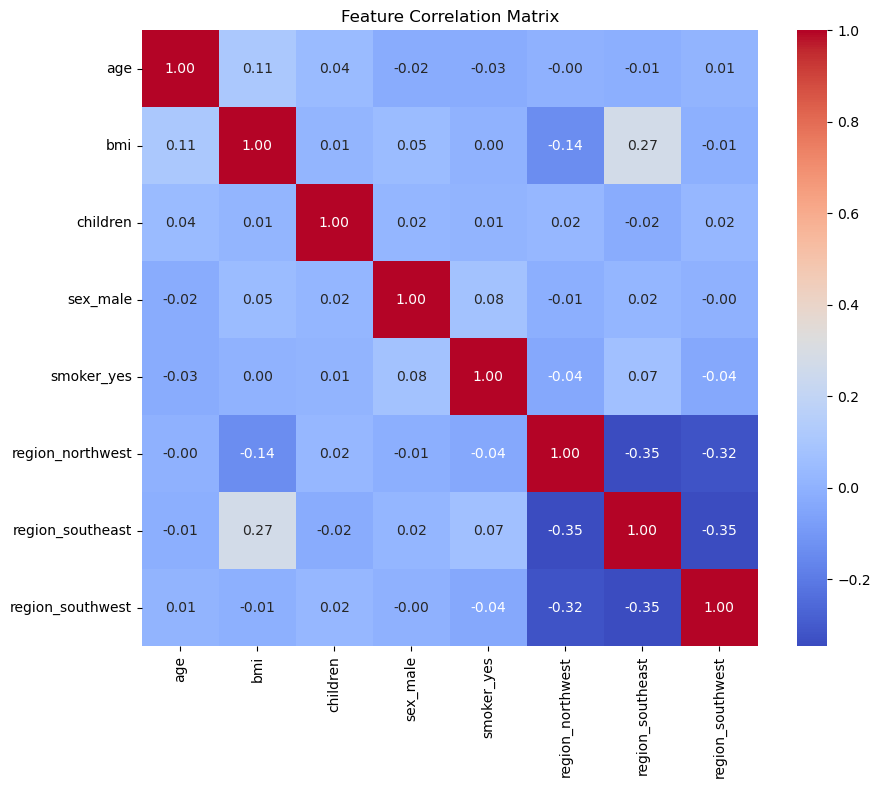

In [9]:
# Correlation matrix (on scaled numeric + binary/dummies)
corr = X_scaled.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix')
plt.show()



Interpret VIF results: look for features with VIF > 5 (or >10) indicating problematic multicollinearity. Recommended actions:
- If two features are highly correlated and represent similar business meaning, drop or combine them (e.g., if `bmi` correlates strongly with `smoker`-related behaviors — though in practice these are different concepts).
- Use principal components or partial least squares for prediction-focused models, but prefer interpretable features for business decision-making.

Dataset shape: (1338, 7)

Data types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Numeric columns: ['age', 'bmi', 'children', 'charges']
Categorical columns: ['sex', 'smoker', 'region']

VIF Values:
             Feature       VIF
0               age  1.016822
1               sex  1.008900
2               bmi  1.106630
3          children  1.004011
4            smoker  1.012074
5  region_northwest  1.518823
6  region_southeast  1.652230
7  region_southwest  1.529411

Linear Regression Results
MSE: 33596915.851361476
R2 Score: 0.7835929767120722

Ridge Regression Results
MSE: 33604956.543377645
R2 Score: 0.7835411843918457


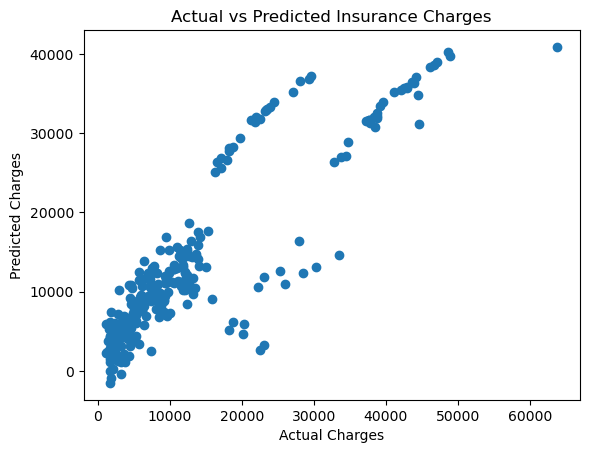

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load dataset
df = pd.read_csv("insurance.csv")

# -------------------------------
# Task 2: Data Inspection
# -------------------------------
print("Dataset shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

numeric_cols = df.select_dtypes(include=["int64","float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns
print("\nNumeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))

# -------------------------------
# Task 3: Data Cleaning & Encoding
# -------------------------------
df["sex"] = df["sex"].map({"male":1, "female":0})
df["smoker"] = df["smoker"].map({"yes":1, "no":0})
df = pd.get_dummies(df, columns=["region"], drop_first=True)

# Features & target
X = df.drop("charges", axis=1)
y = df["charges"]

# -------------------------------
# Task 4: Feature Scaling
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Task 5: Multicollinearity Check (VIF)
# -------------------------------
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
print("\nVIF Values:\n", vif_data)

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -------------------------------
# Model Training (Linear Regression)
# -------------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("\nLinear Regression Results")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# -------------------------------
# Ridge Regression (Fix Multicollinearity)
# -------------------------------
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

print("\nRidge Regression Results")
print("MSE:", mean_squared_error(y_test, ridge_pred))
print("R2 Score:", r2_score(y_test, ridge_pred))

# -------------------------------
# Visualization: Actual vs Predicted
# -------------------------------
plt.scatter(y_test, ridge_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()